## **Exploratory Data Analysis**

### **Imports**

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### **Loading Dataset**

In [3]:
df = pd.read_csv('../data/data.csv')

df.head(5)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### **Data Structure and Quality Check**

In [12]:
print("Dataset Shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("Data Types & Missing Values")
print(df.info())
print("\nMissing Values Count:")
print(df.isnull().sum())

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

Dataset Shape
Rows: 4600, Columns: 18

Data Types & Missing Values
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[us]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  street         4

### **Data Anomaly Identification**

In [13]:
print("\nSummary Statistics (Numeric Features)")
print(df.describe().T)

# Check for zero/unrealistic prices and room counts
invalid_prices = df[df["price"] == 0]
invalid_rooms = df[(df["bedrooms"] == 0) & (df["bathrooms"] == 0)]
print(f"\nRecords with price == 0: {len(invalid_prices)}")
print(f"Records with 0 bedrooms AND 0 bathrooms: {len(invalid_rooms)}")


Summary Statistics (Numeric Features)
                count                        mean                  min  \
date             4600  2014-06-07 03:14:42.782608  2014-05-02 00:00:00   
price          4600.0               551962.988473                  0.0   
bedrooms       4600.0                     3.40087                  0.0   
bathrooms      4600.0                    2.160815                  0.0   
sqft_living    4600.0                 2139.346957                370.0   
sqft_lot       4600.0                14852.516087                638.0   
floors         4600.0                    1.512065                  1.0   
waterfront     4600.0                    0.007174                  0.0   
view           4600.0                    0.240652                  0.0   
condition      4600.0                    3.451739                  1.0   
sqft_above     4600.0                 1827.265435                370.0   
sqft_basement  4600.0                  312.081522                  0.0   

### **Data Cleaning & Target Transformation**

In [14]:
# Create a copy for cleaning
df_clean = df.copy()

# Define cleaning criteria
initial_rows = len(df_clean)

# Filter out zero price records and extreme price outliers ( > $5M )
valid_price_mask = (df_clean['price'] > 0) & (df_clean['price'] < 5_000_000)

# Filter out properties with 0 bedrooms AND 0 bathrooms
valid_rooms_mask = ~((df_clean['bedrooms'] == 0) & (df_clean['bathrooms'] == 0))

# Apply filters
df_clean = df_clean[valid_price_mask & valid_rooms_mask].copy()

# Summary report
removed_rows = initial_rows - len(df_clean)
print(f"Cleaning Summary")
print(f"Original Dataset Rows : {initial_rows}")
print(f"Cleaned Dataset Rows  : {len(df_clean)}")
print(f"Total Rows Removed    : {removed_rows} ({removed_rows / initial_rows * 100:.2f}%)")
print(f"Remaining Price Range : ${df_clean['price'].min():,.2f} to ${df_clean['price'].max():,.2f}")

Cleaning Summary
Original Dataset Rows : 4600
Cleaned Dataset Rows  : 4546
Total Rows Removed    : 54 (1.17%)
Remaining Price Range : $7,800.00 to $4,668,000.00


### **Log Transformation of Target Variable**
Log-transforming `price` converts a heavily skewed distribution with extreme multi-million dollar outliers into a symmetric, bell-shaped curve. This prevents high-priced mansions from dominating model errors and forces algorithms to optimize for relative percentage errors rather than absolute dollar differences.

In [15]:
import numpy as np

# Apply natural log transformation (log1p handles log(1 + x) safely)
df_clean['log_price'] = np.log1p(df_clean['price'])

# Inspect target summary statistics before vs. after transformation
print("Target Summary Statistics")
print("Raw Price   -> Mean:", f"${df_clean['price'].mean():,.2f}", "| Median:", f"${df_clean['price'].median():,.2f}", "| Skewness:", round(df_clean['price'].skew(), 2))
print("Log Price   -> Mean:", f"{df_clean['log_price'].mean():.4f}", "| Median:", f"{df_clean['log_price'].median():.4f}", "| Skewness:", round(df_clean['log_price'].skew(), 2))

Target Summary Statistics
Raw Price   -> Mean: $547,753.54 | Median: $465,000.00 | Skewness: 3.1
Log Price   -> Mean: 13.0623 | Median: 13.0498 | Skewness: 0.18


### **Cell 8: Plot Target Distribution (Before vs. After)**

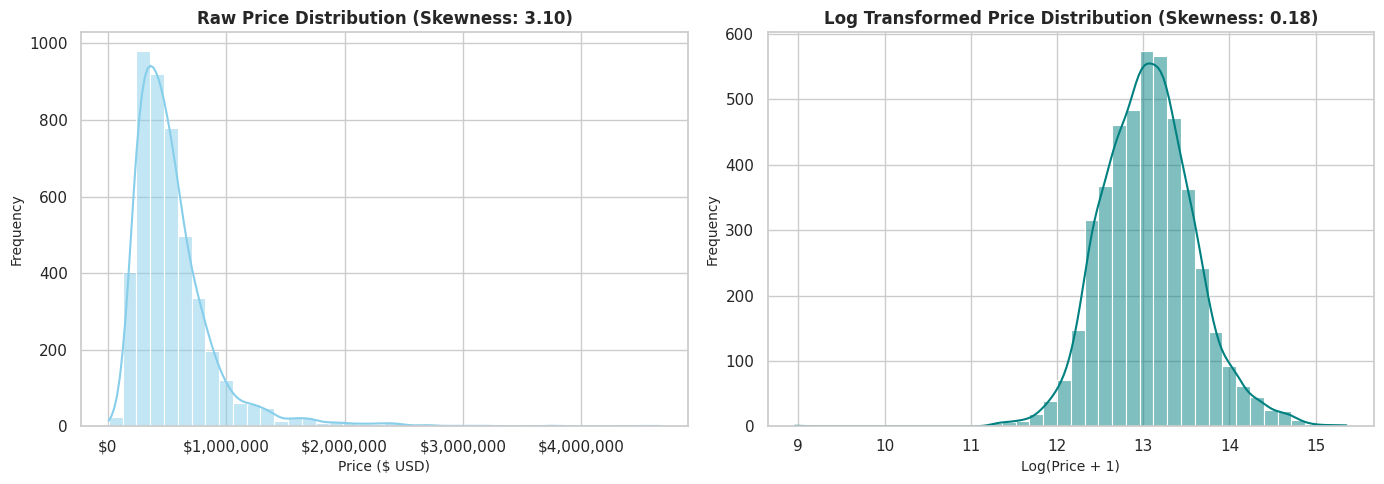

In [18]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw Price Distribution
sns.histplot(df_clean['price'], kde=True, ax=axes[0], color='skyblue', bins=40)
axes[0].set_title(f"Raw Price Distribution (Skewness: {df_clean['price'].skew():.2f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Price ($ USD)", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)
axes[0].xaxis.set_major_formatter('${x:,.0f}')

# Plot 2: Log Price Distribution
sns.histplot(df_clean['log_price'], kde=True, ax=axes[1], color='teal', bins=40)
axes[1].set_title(f"Log Transformed Price Distribution (Skewness: {df_clean['log_price'].skew():.2f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Log(Price + 1)", fontsize=10)
axes[1].set_ylabel("Frequency", fontsize=10)

plt.tight_layout()
plt.show()

### **Sanity Check Math (sqft_living equation)**

In [20]:
# Verify structural identity: sqft_living == sqft_above + sqft_basement
sqft_diff = df_clean['sqft_living'] - (df_clean['sqft_above'] + df_clean['sqft_basement'])
mismatches = (sqft_diff != 0).sum()

print("Structural Sanity Check")
print(f"Total Rows Checked : {len(df_clean)}")
print(f"Mismatched Rows    : {mismatches}")

if mismatches == 0:
    print("Sanity Check Passed: sqft_living is exactly sqft_above + sqft_basement for all rows.")
else:
    print(f"⚠ Warning: Found {mismatches} rows where sqft values do not sum up.")

Structural Sanity Check
Total Rows Checked : 4546
Mismatched Rows    : 0
Sanity Check Passed: sqft_living is exactly sqft_above + sqft_basement for all rows.


### **Correlation Heatmap**

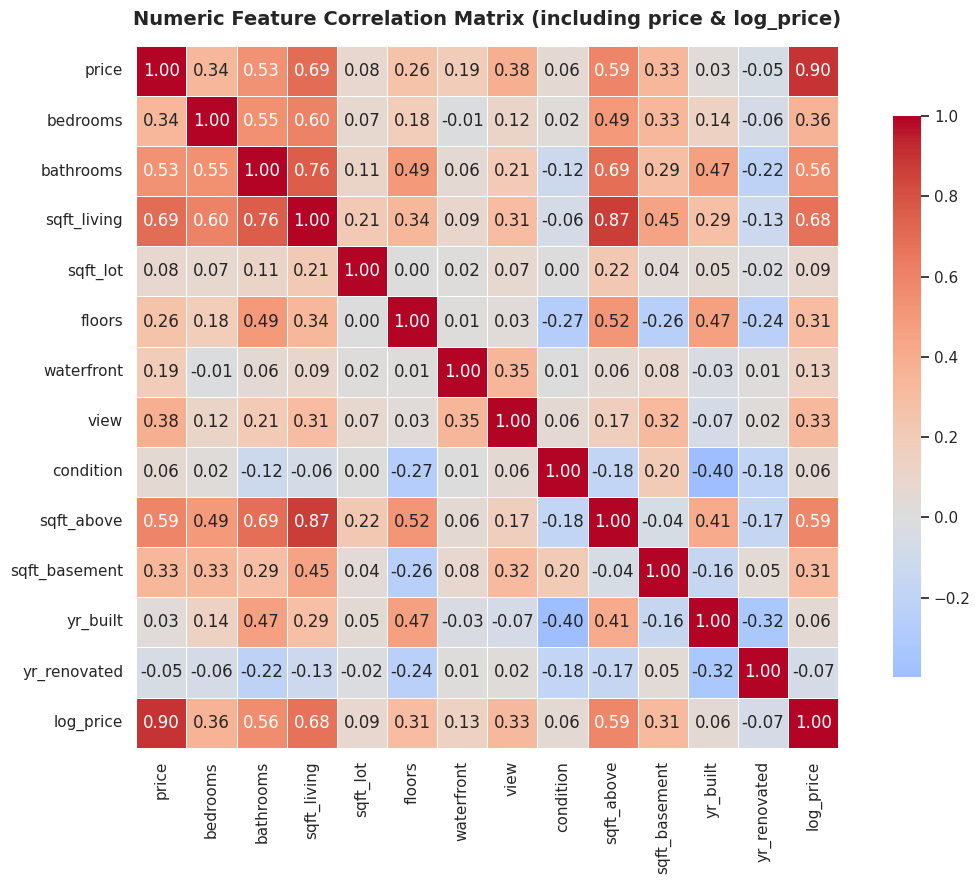

--- Top Correlations with log_price ---
sqft_living      0.677297
sqft_above       0.586159
bathrooms        0.556158
bedrooms         0.363724
view             0.326596
sqft_basement    0.313417
floors           0.310323
waterfront       0.132701
sqft_lot         0.086751
condition        0.060891
yr_built         0.060089
yr_renovated    -0.066669
Name: log_price, dtype: float64


In [21]:
# Select numerical columns for correlation analysis
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Compute Pearson correlation matrix
corr_matrix = df_clean[num_cols].corr()

# Plot annotated correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Numeric Feature Correlation Matrix (including price & log_price)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print top features correlated with target
top_corr = corr_matrix['log_price'].sort_values(ascending=False)
print("--- Top Correlations with log_price ---")
print(top_corr.drop(['price', 'log_price']))

### **Categorical & Location Analysis**

/tmp/ipykernel_18179/1273573771.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


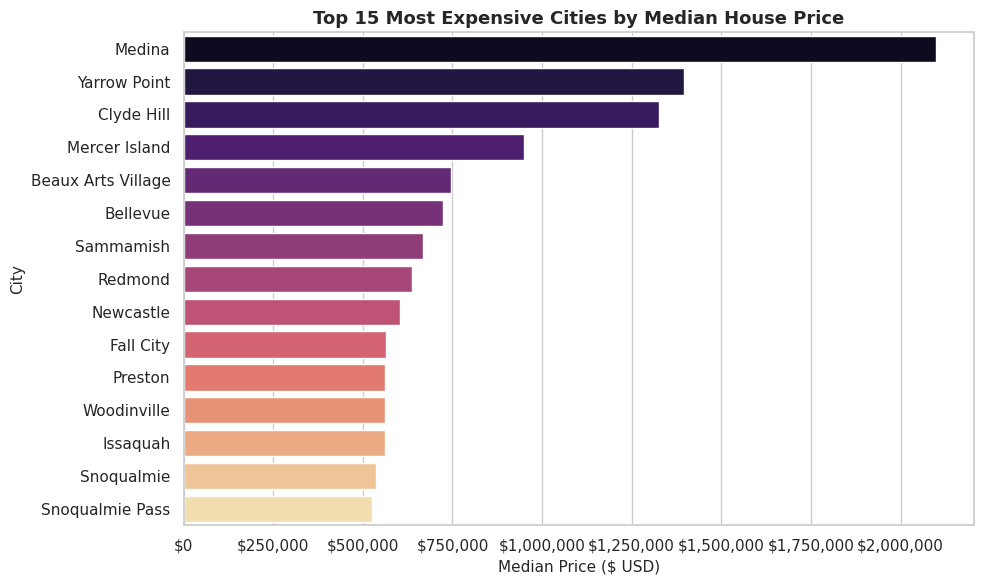

In [22]:
# Calculate Price per Square Foot
df_clean['price_per_sqft'] = df_clean['price'] / df_clean['sqft_living']

# Group by City and calculate median stats
city_stats = df_clean.groupby('city').agg(
    median_price=('price', 'median'),
    median_price_per_sqft=('price_per_sqft', 'median'),
    property_count=('price', 'count')
).reset_index()

# Group by Zip Code and calculate median stats
zip_stats = df_clean.groupby('statezip').agg(
    median_price=('price', 'median'),
    median_price_per_sqft=('price_per_sqft', 'median'),
    property_count=('price', 'count')
).reset_index()

# Get Top 15 most expensive cities by median price
top_15_cities = city_stats.sort_values(by='median_price', ascending=False).head(15)

# Plot Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_15_cities, 
    x='median_price', 
    y='city', 
    palette='magma'
)
plt.title("Top 15 Most Expensive Cities by Median House Price", fontsize=13, fontweight='bold')
plt.xlabel("Median Price ($ USD)", fontsize=11)
plt.ylabel("City", fontsize=11)
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.tight_layout()
plt.show()

### **Structural Visualizations**

/tmp/ipykernel_18179/488287788.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_18179/488287788.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


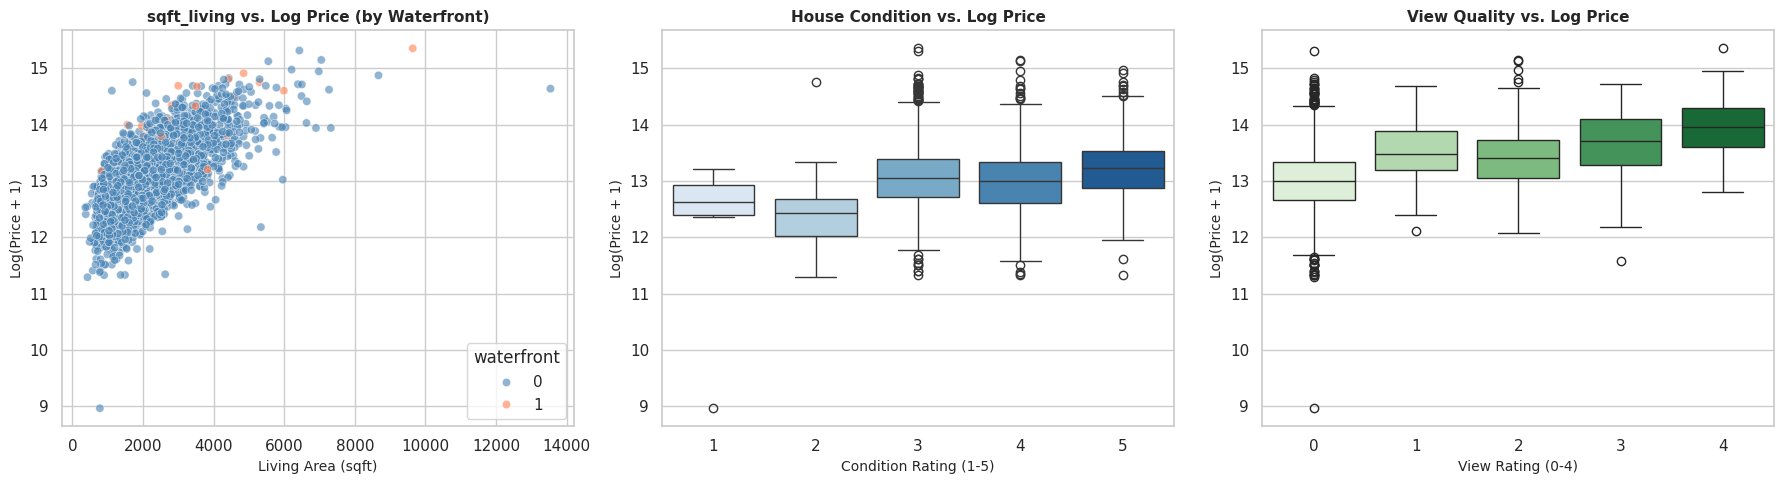

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: sqft_living vs log_price (hue: waterfront)
sns.scatterplot(
    data=df_clean, 
    x='sqft_living', 
    y='log_price', 
    hue='waterfront', 
    palette={0: 'steelblue', 1: 'coral'}, 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title("sqft_living vs. Log Price (by Waterfront)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Living Area (sqft)", fontsize=10)
axes[0].set_ylabel("Log(Price + 1)", fontsize=10)

# Plot 2: condition vs log_price
sns.boxplot(
    data=df_clean, 
    x='condition', 
    y='log_price', 
    palette='Blues', 
    ax=axes[1]
)
axes[1].set_title("House Condition vs. Log Price", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Condition Rating (1-5)", fontsize=10)
axes[1].set_ylabel("Log(Price + 1)", fontsize=10)

# Plot 3: view vs log_price
sns.boxplot(
    data=df_clean, 
    x='view', 
    y='log_price', 
    palette='Greens', 
    ax=axes[2]
)
axes[2].set_title("View Quality vs. Log Price", fontsize=11, fontweight='bold')
axes[2].set_xlabel("View Rating (0-4)", fontsize=10)
axes[2].set_ylabel("Log(Price + 1)", fontsize=10)

plt.tight_layout()
plt.show()

### **Key Findings & EDA Summary**

#### 1. Data Quality & Cleaning
* **Zero-Price Records:** Removed **49 rows** where `price == 0`[cite: 3, 4] and dropped corrupted records with **0 bedrooms and 0 bathrooms**.
* **Outlier Filtering:** Filtered extreme high-end outliers (> $5M) to prevent multi-million-dollar mansions from skewing loss functions.
* **Structural Verification:** Verified that `sqft_living` exactly equals `sqft_above + sqft_basement` across all dataset rows.

#### 2. Target Variable Selection (`log_price`)
* **Skewness Reduction:** Raw house prices exhibited extreme right-skewness ($3.10$)[cite: 4]. Applying `np.log1p()` normalized the target distribution, reducing skewness to **$0.18$**[cite: 4].
* **Optimization:** Training models on `log_price` stabilizes error variance (homoscedasticity) and shifts the optimization goal toward relative percentage error.

#### 3. Key Feature Drivers & Collinearity
* **Primary Drivers:** `sqft_living` ($r = 0.68$), `sqft_above` ($r = 0.59$), and `bathrooms` ($r = 0.56$) show the strongest positive linear relationships with `log_price`[cite: 3].
* **Multicollinearity:** Strong collinearity observed between `sqft_living` and `sqft_above` ($r = 0.87$)[cite: 3].
* **Location Premium:** Clear geographic pricing clusters emerged; top luxury areas like **Medina** ($> \$2\text{M}$ median price) and **Yarrow Point** significantly command higher valuations[cite: 2].
* **Qualitative Assets:** Higher `view` ratings ($0\text{–}4$)[cite: 1] and `waterfront` indicators[cite: 1] demonstrate noticeable baseline price jumps across similar square footages.

### **Next Steps**
Proceed to `notebooks/02_feature_engineering.ipynb` to construct model features:
1. **Age & History:** Calculate `house_age` (`yr_built`) and `years_since_renovation`.
2. **Ratios & Densities:** Create `price_per_sqft`, `living_to_lot_ratio`, and `bed_to_bath_ratio`.
3. **Location Encoding:** Target-encode `city` and `statezip` according to median `log_price` distributions.